In [1]:
import sys
import pandas as pd
sys.path.append('..')
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from src.data_loader import fetch_prices,get_returns
from src.backtest import backtest
from src.metrics import backtest_metrics

In [2]:
tickers = [
    "V",
    "MSFT",
    "JNJ"]
start_date='2024-01-01'
end_date='2026-01-01'

In [3]:
df = fetch_prices(tickers, start_date, end_date)
daily_returns = get_returns(df)

In [4]:
daily_returns

Ticker,JNJ,MSFT,V
Date,,,
2024-01-03,0.006232,-0.000728,-0.003444
2024-01-04,-0.002115,-0.007203,0.006298
2024-01-05,0.003108,-0.000517,0.000308
2024-01-08,0.002479,0.018696,0.010915
2024-01-09,0.000619,0.002931,0.003005
...,...,...,...
2025-12-24,0.009672,0.002400,0.004968
2025-12-26,-0.000722,-0.000635,-0.000394
2025-12-29,-0.000337,-0.001252,-0.001099


In [5]:
classical_returns, classical_weights_history = backtest(daily_returns, tickers)
metrics = backtest_metrics(classical_returns)
print(metrics)
cum_returns = (1 + classical_returns).cumprod()

Window 1/3
Window 2/3
Window 3/3
{'annual_return': 0.12692625588019207, 'annual_volatility': 0.22697456769131216, 'sharpe_ratio': 0.33892015595691144, 'max_drawdown': -0.14507214752524888}


In [6]:
lstm_returns, lstm_weights_history = backtest(daily_returns, tickers,method='lstm')
metrics = backtest_metrics(lstm_returns)
print(metrics)

lstm_cum_returns = (1 + lstm_returns).cumprod()

Window 1/3
Window 2/3
Window 3/3
{'annual_return': 0.2224766471347117, 'annual_volatility': 0.23670709652105829, 'sharpe_ratio': 0.7286500897930097, 'max_drawdown': -0.20312727485909488}


In [7]:
gru_returns, gru_weights_history = backtest(daily_returns, tickers,method='gru')
gru_metrics = backtest_metrics(gru_returns)
print(gru_metrics)

gru_cum_returns = (1 + gru_returns).cumprod()

Window 1/3
Window 2/3
Window 3/3
{'annual_return': 0.11339765719197581, 'annual_volatility': 0.16947239798430658, 'sharpe_ratio': 0.37408839401591837, 'max_drawdown': -0.14831837956695593}


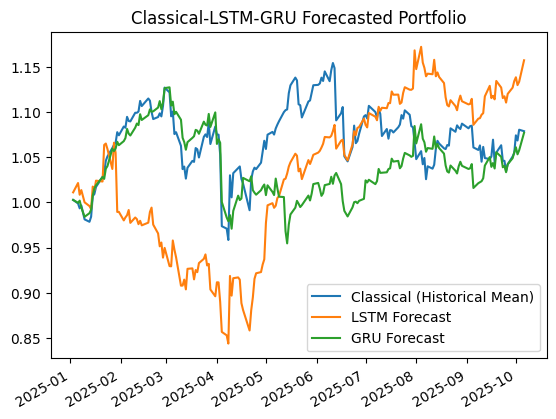

In [8]:
cum_returns.plot(label="Classical (Historical Mean)")
lstm_cum_returns.plot(label="LSTM Forecast")
gru_cum_returns.plot(label="GRU Forecast")

plt.legend()
plt.title("Classical-LSTM-GRU Forecasted Portfolio")
plt.show()

In [9]:
import pandas as pd
summary_df = pd.DataFrame([
    {"method": "classical", **backtest_metrics(classical_returns)},
    {"method": "lstm", **backtest_metrics(lstm_returns)},
    {"method": "gru", **backtest_metrics(gru_returns)}
])
summary_df.to_csv("../results/backtest_summary.csv", index=False)
summary_df

,method,annual_return,annual_volatility,sharpe_ratio,max_drawdown
0,classical,0.126926,0.226975,0.338920,-0.145072
1,lstm,0.222477,0.236707,0.728650,-0.203127
2,gru,0.113398,0.169472,0.374088,-0.148318
